# 03. Data Analysis & Clustering (PySpark)

Notebook ini mengikuti format bertahap seperti notebook preprocessing. Isi notebook dimulai dari membaca data bersih dari MongoDB, lalu analisis statistik deskriptif, visualisasi persebaran data, penentuan jumlah cluster optimal, pelatihan model clustering, evaluasi Silhouette Score, hingga penyimpanan hasil cluster untuk interpretasi zona rawan gempa.

### Tahap 1: Import Library & Load Konfigurasi
Menyiapkan environment PySpark, mengaktifkan library eksternal (pandas, matplotlib, seaborn), serta mengambil *environment variables*.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.functions import col, count, avg, min, max, stddev_samp, round, date_format, rand, row_number
from pyspark.ml.functions import array_to_vector
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
SPARK_MASTER = 'local[*]'
MONGO_URI = 'mongodb://localhost:27017'
MONGO_DB = 'earthquake_db'
MONGO_CLEAN_COL = 'clean_earthquakes_emsc'
MONGO_EDA_SUMMARY_COL = 'eda_summary_emsc'
MONGO_MODEL_METRICS_COL = 'model_metrics_emsc'
MONGO_KMEANS_COL = 'kmeans_results_emsc'
MONGO_BISECTING_COL = 'bisecting_results_emsc'
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11


### Tahap 2: Menyalakan Spark Session & Membaca Data Bersih
Membuka sesi di atas master PySpark dan mengambil data yang sudah berada di koleksi `clean_earthquakes`.

In [2]:
spark = SparkSession.builder \
    .appName('EarthquakeAnalysis') \
    .master(SPARK_MASTER) \
    .config('spark.mongodb.read.connection.uri', MONGO_URI) \
    .config('spark.mongodb.write.connection.uri', MONGO_URI) \
    .config('spark.jars.packages', 'org.mongodb.spark:mongo-spark-connector_2.12:10.3.0') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark Session aktif di master: {SPARK_MASTER}')

your 131072x1 screen size is bogus. expect trouble
26/06/23 08:19:07 WARN Utils: Your hostname, Lenovo-LOQ-15 resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/23 08:19:07 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/yudnata/.ivy2/cache
The jars for the packages stored in: /home/yudnata/.ivy2/jars
org.mongodb.spark#mongo-spark-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-77533c14-d7a5-4b33-ad60-549aa917d5be;1.0
	confs: [default]
	found org.mongodb.spark#mongo-spark-connector_2.12;10.3.0 in central
	found org.mongodb#mongodb-driver-sync;4.8.2 in central
	[4.8.2] org.mongodb#mongodb-driver-sync;[4.8.1,4.8.99)
	found org.mongodb#bson;4.8.2 in central
	found org.mongodb#mongodb-driver-core;4.8.2 in central
	found org.mongodb#bson-record-codec;4.8.2 in central
:: resolution report :: resolve 1345ms :: artifacts dl 13ms
	:: modules in use:
	org.mongodb#bson;4.8.2 from central in [default]
	org.mongodb#bson-record-codec;4.8.2 from central in [default]
	org.mongodb#mongodb-driver-core;4.8.2 from central in [default]
	org.mongodb#mongodb-driver-sync;4.8.2 from central in [default]
	org.mongodb.spark#mongo-spark-connect

Spark Session aktif di master: local[*]


In [3]:
df_clean = spark.read.format('mongodb') \
    .option('database', MONGO_DB) \
    .option('collection', MONGO_CLEAN_COL) \
    .load()
print(f'Total data bersih: {df_clean.count()} baris')
df_clean.printSchema()
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=['x', 'y', 'z'], outputCol='features')
df_clean = assembler.transform(df_clean)
df_clean.createOrReplaceTempView('earthquake_clean')
df_clean.select('time', 'country', 'latitude', 'longitude', 'depth', 'mag').show(5, truncate=False)


Total data bersih: 73219 baris
root
 |-- _id: string (nullable = true)
 |-- auth: string (nullable = true)
 |-- country: string (nullable = true)
 |-- depth: double (nullable = true)
 |-- depth_log: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- mag: double (nullable = true)
 |-- place: string (nullable = true)
 |-- raw_features: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- scaled_features: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- time: timestamp (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- z: double (nullable = true)



+----------------------+-----------+--------+---------+-----+---+
|time                  |country    |latitude|longitude|depth|mag|
+----------------------+-----------+--------+---------+-----+---+
|2025-01-17 03:13:43   |Indonesia  |0.07    |126.14   |10.0 |3.6|
|2025-01-14 14:45:54   |ICELAND    |64.662  |-17.546  |7.0  |3.3|
|2025-01-13 22:34:32.8 |GREECE     |38.1619 |22.0523  |13.4 |2.6|
|2025-01-13 15:14:03   |EL SALVADOR|12.82   |-88.63   |35.0 |3.8|
|2025-01-12 21:51:40.75|ITALY      |46.4382 |12.8243  |7.6  |4.0|
+----------------------+-----------+--------+---------+-----+---+
only showing top 5 rows



### Tahap 3: Analisis Statistik Deskriptif
Meninjau karakteristik dasar data gempa yang sudah bersih sebelum masuk ke visualisasi dan clustering. Ringkasan ini juga disimpan ke collection `eda_summary` agar hasil EDA punya artefak tersendiri di MongoDB.

In [4]:
descriptive_stats = df_clean.select('latitude', 'longitude', 'depth', 'mag', 'depth_log').summary('count', 'mean', 'stddev', 'min', '25%', '50%', '75%', 'max')
descriptive_stats.show(truncate=False)

summary_rows = descriptive_stats.collect()
eda_summary_rows = []
for row in summary_rows:
    metric_name = row['summary']
    for feature_name in descriptive_stats.columns:
        if feature_name != 'summary':
            eda_summary_rows.append((feature_name, metric_name, row[feature_name]))

eda_summary_df = spark.createDataFrame(eda_summary_rows, ['feature', 'metric', 'value'])
eda_summary_df.write.format('mongodb') \
    .mode('overwrite') \
    .option('database', MONGO_DB) \
    .option('collection', MONGO_EDA_SUMMARY_COL) \
    .save()

print(f'Ringkasan EDA berhasil disimpan ke collection {MONGO_EDA_SUMMARY_COL}.')

time_range = df_clean.selectExpr('min(time) as earliest_time', 'max(time) as latest_time', 'count(*) as total_rows')
time_range.show(truncate=False)

country_counts = df_clean.groupBy('country').agg(count('*').alias('quake_count')).orderBy(col('quake_count').desc()).limit(10)
country_counts.show(truncate=False)

26/06/23 08:19:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+-----------------+-----------------+------------------+
|summary|latitude          |longitude         |depth            |mag              |depth_log         |
+-------+------------------+------------------+-----------------+-----------------+------------------+
|count  |73219             |73219             |73219            |73219            |73219             |
|mean   |12.818599704994503|12.294580425845806|47.62148622625373|3.472255835234419|3.130077115108675 |
|stddev |27.470872491628676|105.49723046692478|77.3161458779547 |0.68732193022119 |1.1789916009626216|
|min    |-65.6088          |-179.9971         |0.0              |2.6              |0.0               |
|25%    |-6.46             |-86.2             |10.0             |3.0              |2.3978952727983707|
|50%    |15.036            |25.632            |15.0             |3.3              |2.772588722239781 |
|75%    |36.63             |121.75            |51.8             |3.9     

Ringkasan EDA berhasil disimpan ke collection eda_summary_emsc.
+----------------------+-------------------+----------+
|earliest_time         |latest_time        |total_rows|
+----------------------+-------------------+----------+
|2025-01-01 08:17:15.15|2026-01-01 07:58:33|73219     |
+----------------------+-------------------+----------+

+-------------+-----------+
|country      |quake_count|
+-------------+-----------+
|Indonesia    |13370      |
|MEXICO       |8069       |
|CHILE        |5694       |
|United States|5485       |
|GREECE       |4269       |
|TURKEY       |3246       |
|Russia       |3100       |
|PHILIPPINES  |2872       |
|ARGENTINA    |2118       |
|JAPAN        |1670       |
+-------------+-----------+



### Tahap 4: Analisis Persebaran dan Distribusi Data
Bagian ini memeriksa pola distribusi gempa melalui frekuensi bulanan, wilayah dengan kejadian tertinggi, serta hubungan awal antara magnitude dan kedalaman.

In [5]:
numeric_features = ['latitude', 'longitude', 'depth', 'mag', 'x', 'y', 'z', 'depth_log']

stats_query = ' UNION ALL '.join([
    f"SELECT '{feature}' AS feature, round(avg({feature}), 4) AS mean, round(min({feature}), 4) AS minimum, round(max({feature}), 4) AS maximum, round(stddev_samp({feature}), 4) AS stddev FROM earthquake_clean"
    for feature in numeric_features
])

stats_df = spark.sql(stats_query)
stats_df.show(truncate=False)

+---------+-------+---------+--------+--------+
|feature  |mean   |minimum  |maximum |stddev  |
+---------+-------+---------+--------+--------+
|latitude |12.8186|-65.6088 |87.0548 |27.4709 |
|longitude|12.2946|-179.9971|179.9994|105.4972|
|depth    |47.6215|0.0      |690.1   |77.3161 |
|mag      |3.4723 |2.6      |8.8     |0.6873  |
|x        |-0.0915|-0.9703  |0.9784  |0.493   |
|y        |-0.0075|-0.9998  |0.9987  |0.7223  |
|z        |0.201  |-0.9107  |0.9987  |0.4318  |
|depth_log|3.1301 |0.0      |6.5383  |1.179   |
+---------+-------+---------+--------+--------+



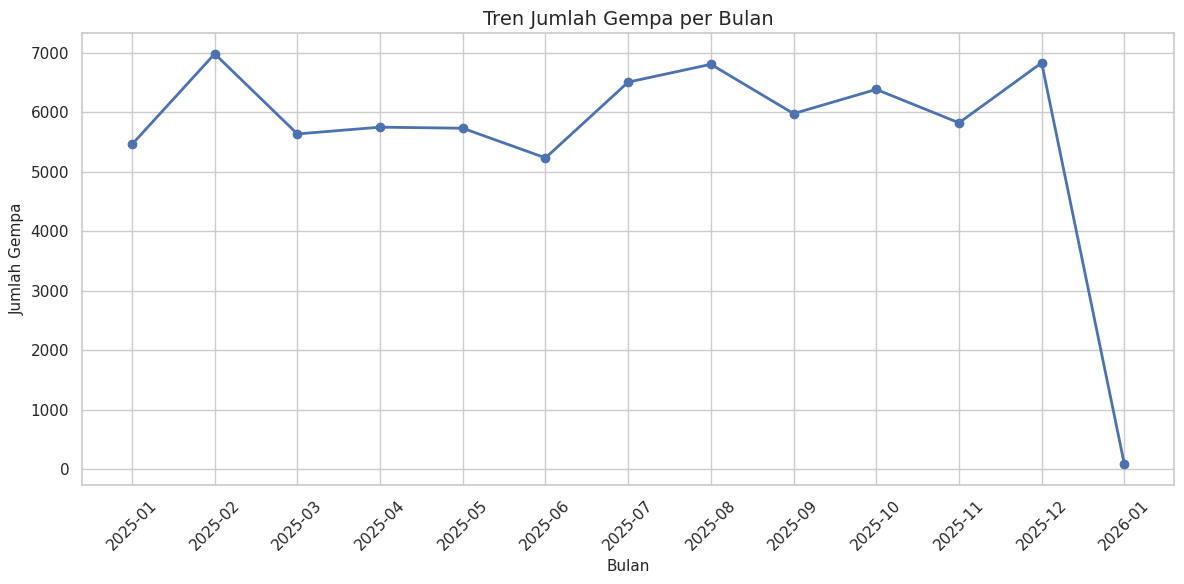

In [6]:
monthly_df = spark.sql("""
SELECT date_format(time, 'yyyy-MM') AS month, count(*) AS quake_count
FROM earthquake_clean
GROUP BY date_format(time, 'yyyy-MM')
ORDER BY month
""")

monthly_pdf = monthly_df.toPandas()

fig, ax = plt.subplots()
ax.plot(monthly_pdf['month'], monthly_pdf['quake_count'], marker='o', linewidth=2)
ax.set_title('Tren Jumlah Gempa per Bulan')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Gempa')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_17795/3122109477.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_region_pdf, x='quake_count', y='country', ax=ax, palette='Blues_r')
/home/yudnata/spark-env/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/yudnata/spark-env/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/yudnata/spark-env/lib/python3.12/site-packa

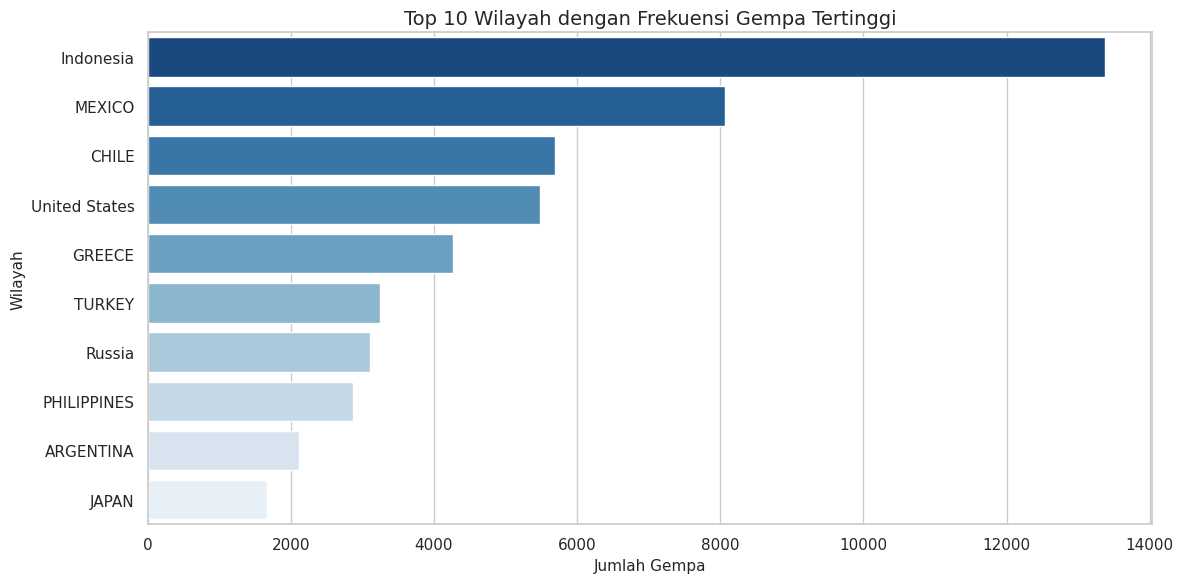

In [7]:
top_region_df = spark.sql("""
SELECT country, count(*) AS quake_count
FROM earthquake_clean
GROUP BY country
ORDER BY quake_count DESC
LIMIT 10
""")

top_region_pdf = top_region_df.toPandas()

fig, ax = plt.subplots()
sns.barplot(data=top_region_pdf, x='quake_count', y='country', ax=ax, palette='Blues_r')
ax.set_title('Top 10 Wilayah dengan Frekuensi Gempa Tertinggi')
ax.set_xlabel('Jumlah Gempa')
ax.set_ylabel('Wilayah')
plt.tight_layout()
plt.show()

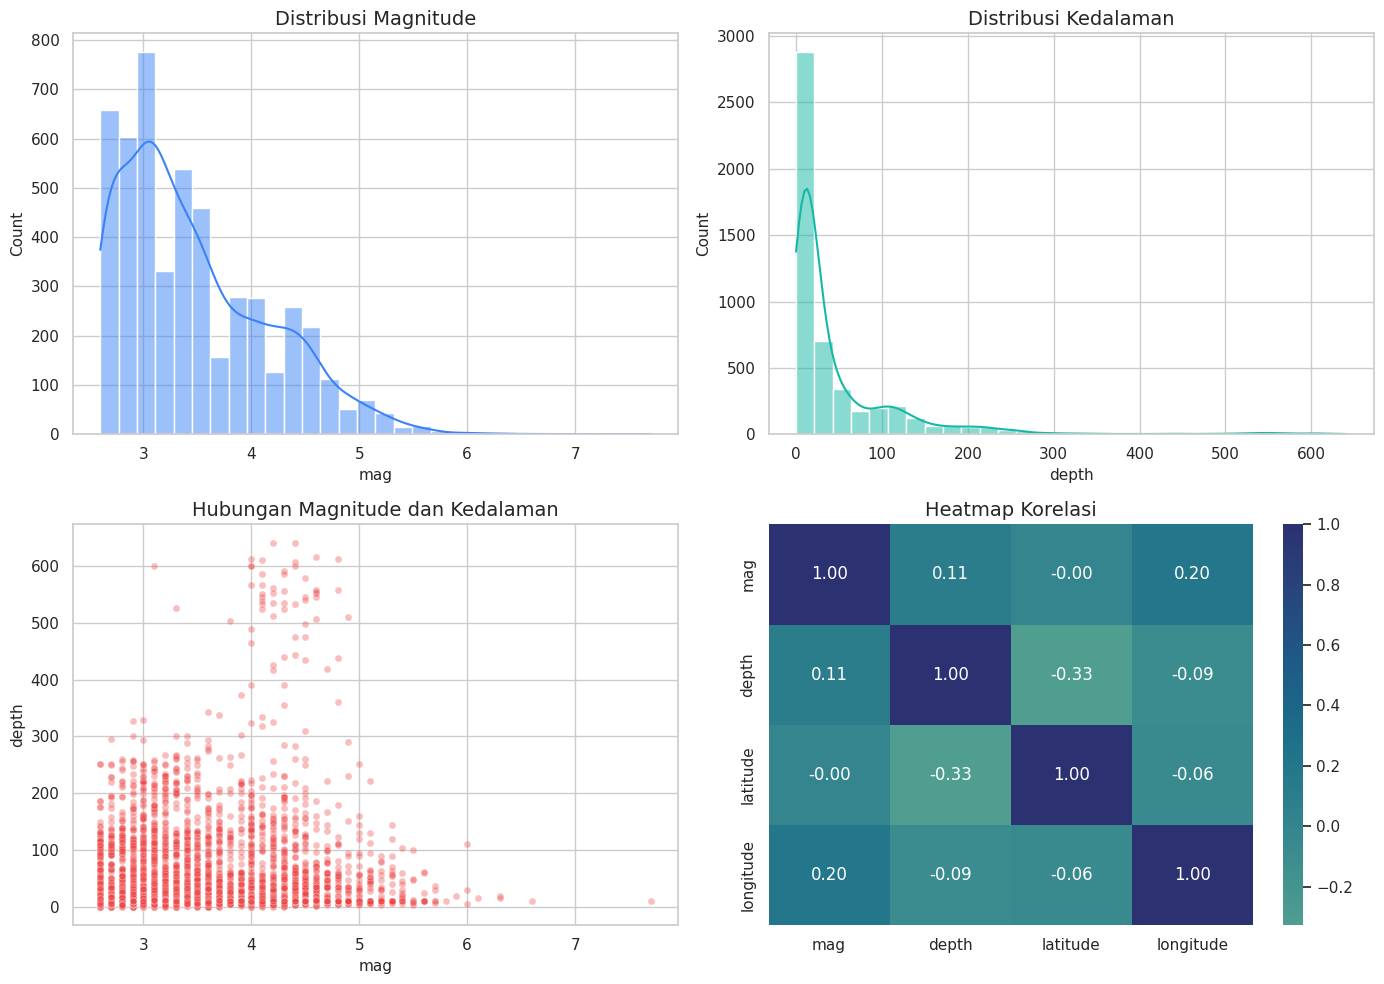

In [8]:
plot_pdf = df_clean.select('mag', 'depth', 'latitude', 'longitude').dropna().sample(False, 0.2, seed=42).limit(5000).toPandas()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(plot_pdf['mag'], bins=30, kde=True, ax=axes[0, 0], color='#3b82f6')
axes[0, 0].set_title('Distribusi Magnitude')
sns.histplot(plot_pdf['depth'], bins=30, kde=True, ax=axes[0, 1], color='#14b8a6')
axes[0, 1].set_title('Distribusi Kedalaman')
sns.scatterplot(data=plot_pdf, x='mag', y='depth', ax=axes[1, 0], alpha=0.35, s=25, color='#ef4444')
axes[1, 0].set_title('Hubungan Magnitude dan Kedalaman')
corr_matrix = plot_pdf.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='crest', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Heatmap Korelasi')
plt.tight_layout()
plt.show()


### Tahap 5: Persiapan Data untuk Clustering
Fitur numerik disusun kembali ke format vector. Selain itu, kita melakukan **Geographical Undersampling** (maks 5.000 titik per negara) agar klaster tidak bias ke wilayah yang memiliki sensor gempa sangat padat (seperti Amerika Serikat).


In [9]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, rand

model_df = df_clean.select('time', 'place', 'country', 'latitude', 'longitude', 'depth', 'mag', 'x', 'y', 'z', 'depth_log', 'scaled_features', 'features').dropna(subset=['features'])

# Geographical Undersampling (Max 5000 per country) for training
window_spec = Window.partitionBy('country').orderBy(rand(42))
training_df = model_df.withColumn('rn', row_number().over(window_spec)) \
                      .filter(col('rn') <= 5000) \
                      .drop('rn')

evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='prediction', metricName='silhouette', distanceMeasure='squaredEuclidean')

print(f'Total data keseluruhan (untuk prediksi): {model_df.count()} baris')
print(f'Total data undersampled (untuk training): {training_df.count()} baris')


Total data keseluruhan (untuk prediksi): 73219 baris
Total data undersampled (untuk training): 60601 baris


### Tahap 6: Penentuan Jumlah Cluster Optimal (Elbow Method)
Tahap ini mencari nilai K yang masuk akal sebelum model clustering dilatih dengan menghitung Within-Cluster Sum of Squares (WCSS) dan Silhouette Score.

In [10]:
k_values = list(range(2, 11))
elbow_rows = []

for k in k_values:
    model = KMeans(k=k, seed=42, featuresCol='features', predictionCol='prediction', maxIter=25).fit(training_df)
    predictions = model.transform(training_df) # Evaluasi siku bisa menggunakan training_df agar lebih cepat
    silhouette = float(evaluator.evaluate(predictions))
    elbow_rows.append((k, float(model.summary.trainingCost), silhouette))

elbow_df = spark.createDataFrame(elbow_rows, ['k', 'wcss', 'silhouette'])
elbow_df.show(truncate=False)

26/06/23 08:20:55 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


+---+------------------+------------------+
|k  |wcss              |silhouette        |
+---+------------------+------------------+
|2  |30989.09741489819 |0.5937527932320478|
|3  |26275.609830278365|0.5156340195148342|
|4  |12174.941751365957|0.719945005626586 |
|5  |8625.338162586992 |0.7348921036528075|
|6  |5834.504403228972 |0.7729430760290806|
|7  |5027.014804365485 |0.7588855861310624|
|8  |3997.9913844833545|0.7605610362349853|
|9  |3593.981251428985 |0.7630639670137686|
|10 |3588.9297421264782|0.6686437046802184|
+---+------------------+------------------+



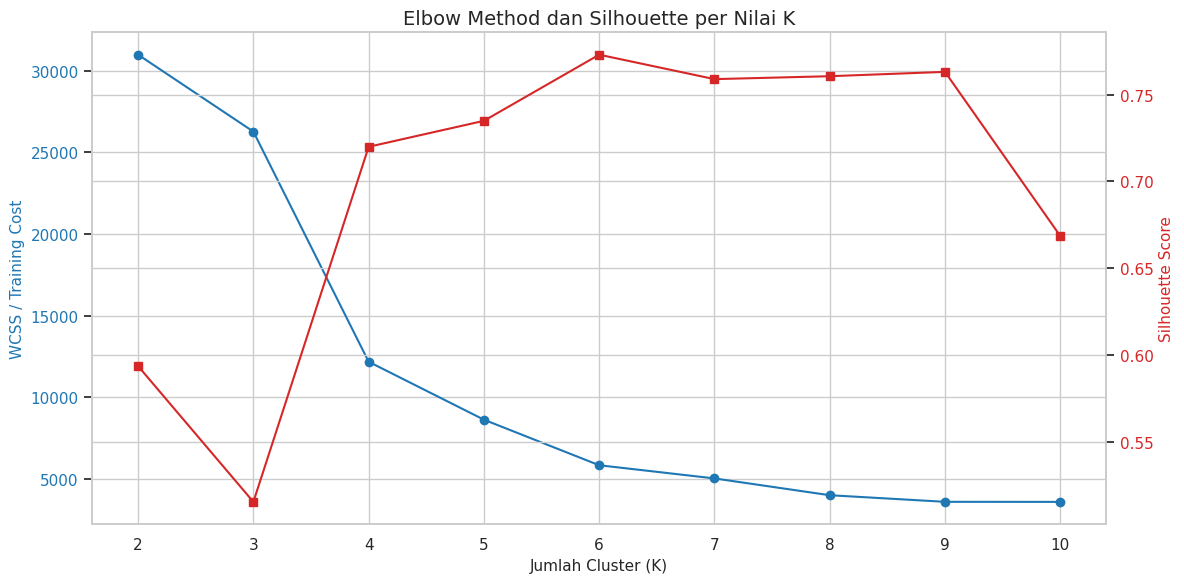

In [11]:
elbow_pdf = elbow_df.toPandas()

fig, ax1 = plt.subplots()
ax1.plot(elbow_pdf['k'], elbow_pdf['wcss'], marker='o', color='#1f77b4', label='WCSS')
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('WCSS / Training Cost', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2 = ax1.twinx()
ax2.plot(elbow_pdf['k'], elbow_pdf['silhouette'], marker='s', color='#d62728', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax1.set_title('Elbow Method dan Silhouette per Nilai K')
plt.tight_layout()
plt.show()

### Tahap 7: Pelatihan Model (K-Means, Bisecting K-Means)
Model clustering dilatih menggunakan data `training_df`, lalu di-apply ke seluruh data `model_df`.


In [12]:
OPTIMAL_K = 8  # Sesuaikan dengan titik siku pada grafik elbow setelah dijalankan

kmeans = KMeans(k=OPTIMAL_K, seed=42, featuresCol='features', predictionCol='kmeans_cluster', maxIter=25)
kmeans_model = kmeans.fit(training_df)
kmeans_result = kmeans_model.transform(model_df)
kmeans_silhouette = float(ClusteringEvaluator(featuresCol='features', predictionCol='kmeans_cluster', metricName='silhouette', distanceMeasure='squaredEuclidean').evaluate(kmeans_result))

print(f'K-Means Silhouette Score: {kmeans_silhouette:.4f}')
kmeans_result.groupBy('kmeans_cluster').agg(count('*').alias('count'), round(avg('mag'), 4).alias('avg_mag'), round(avg('depth'), 4).alias('avg_depth')).orderBy('kmeans_cluster').show(truncate=False)

K-Means Silhouette Score: 0.7689
+--------------+-----+-------+---------+
|kmeans_cluster|count|avg_mag|avg_depth|
+--------------+-----+-------+---------+
|0             |4021 |3.6946 |20.8194  |
|1             |3520 |4.0511 |159.5863 |
|2             |18487|3.4421 |43.1996  |
|3             |9949 |3.3479 |99.4434  |
|4             |5624 |3.1283 |22.4978  |
|5             |14754|3.4924 |35.8103  |
|6             |4909 |4.3371 |46.9638  |
|7             |11955|3.1589 |14.0466  |
+--------------+-----+-------+---------+



In [13]:
bisecting = BisectingKMeans(k=OPTIMAL_K, seed=42, featuresCol='features', predictionCol='bisect_cluster', maxIter=20)
bisecting_model = bisecting.fit(training_df)
bisecting_result = bisecting_model.transform(model_df)
bisecting_silhouette = float(ClusteringEvaluator(featuresCol='features', predictionCol='bisect_cluster', metricName='silhouette', distanceMeasure='squaredEuclidean').evaluate(bisecting_result))

print(f'Bisecting K-Means Silhouette Score: {bisecting_silhouette:.4f}')
bisecting_result.groupBy('bisect_cluster').agg(count('*').alias('count'), round(avg('mag'), 4).alias('avg_mag'), round(avg('depth'), 4).alias('avg_depth')).orderBy('bisect_cluster').show(truncate=False)

Bisecting K-Means Silhouette Score: 0.7075
+--------------+-----+-------+---------+
|bisect_cluster|count|avg_mag|avg_depth|
+--------------+-----+-------+---------+
|0             |2824 |3.9592 |182.9243 |
|1             |9894 |3.3425 |99.8396  |
|2             |14331|3.5012 |36.7697  |
|3             |3355 |3.1249 |11.7006  |
|4             |7621 |3.8793 |37.5291  |
|5             |21637|3.5113 |42.4999  |
|6             |2670 |3.71   |21.0601  |
|7             |10887|3.112  |14.1815  |
+--------------+-----+-------+---------+



### Tahap 8: Visualisasi Persebaran Cluster
Plot hasil klaster ketiga model pada peta koordinat spasial (scatter plot *longitude* vs *latitude*).


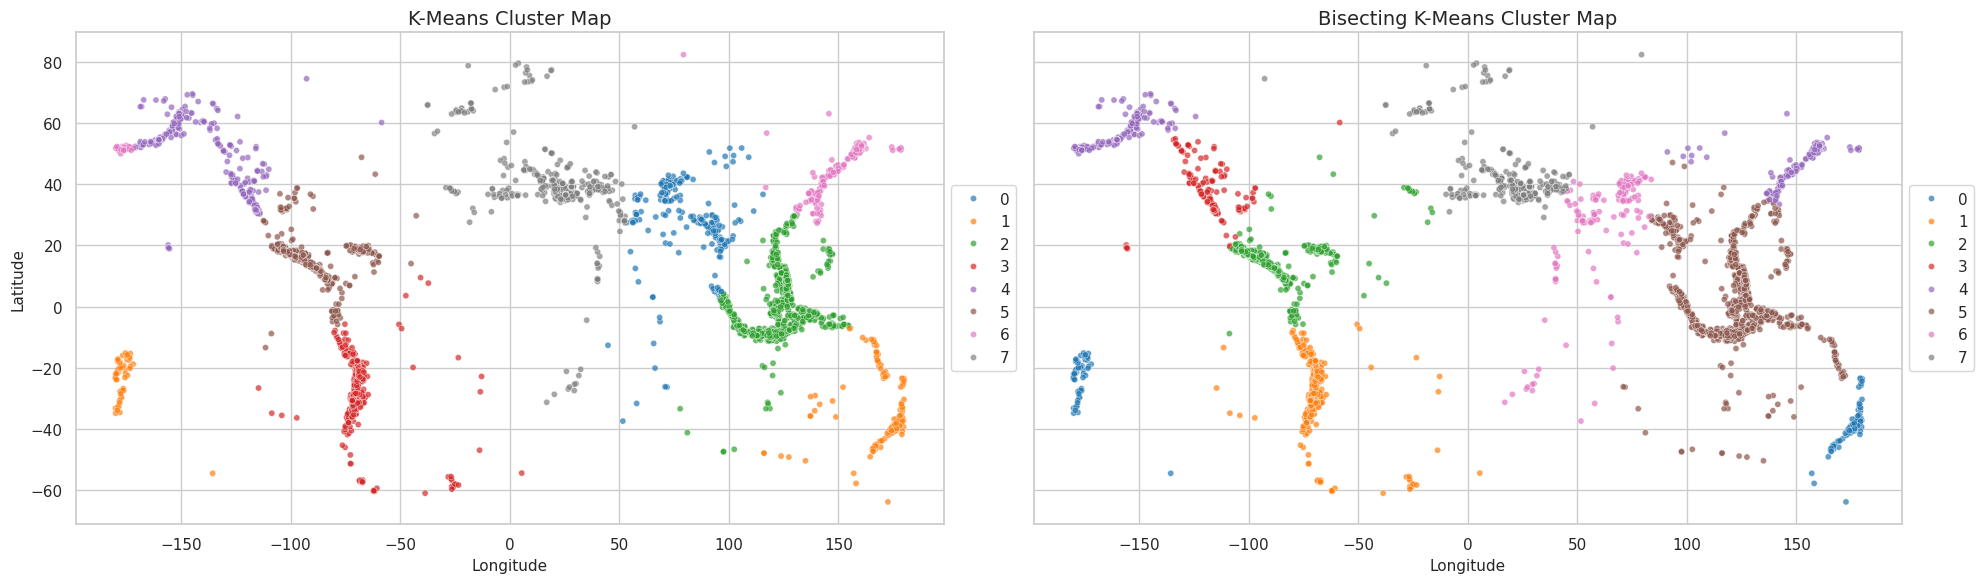

In [14]:
kmeans_plot_pdf = kmeans_result.select('longitude', 'latitude', 'kmeans_cluster', 'mag', 'depth').dropna().sample(False, 0.2, seed=42).limit(5000).toPandas()
bisect_plot_pdf = bisecting_result.select('longitude', 'latitude', 'bisect_cluster', 'mag', 'depth').dropna().sample(False, 0.2, seed=42).limit(5000).toPandas()
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharex=True, sharey=True)
sns.scatterplot(data=kmeans_plot_pdf, x='longitude', y='latitude', hue='kmeans_cluster', palette='tab10', s=20, alpha=0.7, ax=axes[0])
axes[0].set_title('K-Means Cluster Map')
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
sns.scatterplot(data=bisect_plot_pdf, x='longitude', y='latitude', hue='bisect_cluster', palette='tab10', s=20, alpha=0.7, ax=axes[1])
axes[1].set_title('Bisecting K-Means Cluster Map')
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[1].set_xlabel('Longitude')
plt.tight_layout()
plt.show()


### Tahap 9: Evaluasi Clustering
Pengukuran Silhouette Score untuk menentukan seberapa cocok titik data dengan clusternya masing-masing. Hasil evaluasi (`model_metrics`) ini di-save ke MongoDB untuk histori metrik evaluasi model cluster.

In [15]:
comparison_df = spark.createDataFrame([
    ('K-Means', kmeans_silhouette),
    ('Bisecting K-Means', bisecting_silhouette),
], ['model', 'silhouette'])
comparison_df.show(truncate=False)
model_metrics_df = spark.createDataFrame([
    ('Bisecting K-Means', OPTIMAL_K, bisecting_silhouette),
    ('Bisecting K-Means', OPTIMAL_K, bisecting_silhouette)
], ['algorithm', 'k', 'silhouette'])
model_metrics_df.write.format('mongodb') \
    .mode('overwrite') \
    .option('database', MONGO_DB) \
    .option('collection', MONGO_MODEL_METRICS_COL) \
    .save()
print(f'Model metrics berhasil disimpan ke collection {MONGO_MODEL_METRICS_COL}.')


+-----------------+------------------+
|model            |silhouette        |
+-----------------+------------------+
|K-Means          |0.7689435221271219|
|Bisecting K-Means|0.7075220970875105|
+-----------------+------------------+

Model metrics berhasil disimpan ke collection model_metrics_emsc.


### Tahap 10: Penyimpanan Hasil Analisis ke Database
Seluruh label klaster data gempa (`kmeans_cluster`, `bisect_cluster`, `gmm_cluster`) yang dihasilkan akan di-ekstrak beserta kolom aslinya untuk disimpan di MongoDB tanpa fitur tambahan (training). Data inilah yang selanjutnya jadi basis valid untuk proses Visualisasi/Dasboard berikutnya.


In [16]:
kmeans_export = kmeans_result.select('time', 'place', 'country', 'latitude', 'longitude', 'depth', 'mag', 'kmeans_cluster')
bisecting_export = bisecting_result.select('time', 'place', 'country', 'latitude', 'longitude', 'depth', 'mag', 'bisect_cluster')
kmeans_export.write.format('mongodb') \
    .mode('overwrite') \
    .option('database', MONGO_DB) \
    .option('collection', MONGO_KMEANS_COL) \
    .save()
bisecting_export.write.format('mongodb') \
    .mode('overwrite') \
    .option('database', MONGO_DB) \
    .option('collection', MONGO_BISECTING_COL) \
    .save()
print('Hasil clustering berhasil disimpan ke MongoDB.')


Hasil clustering berhasil disimpan ke MongoDB.
